In [1]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.1 MB/s eta 0:00:00


**Test segmentation on ResNet-18**

# Connect google drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# You can choose any image from your validation set or another test set.
TEST_IMAGE_PATH = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Python_Script/Assets/test_images/83_HC.png' # Example path
model_save_path = '/content/drive/MyDrive/Aakash_RB_research/task_1_segmentation/Model_weights/segmentation_resnet18.pth'

In [5]:
# Import libraries
import torch
import torch.nn as nn

import os
import cv2
import numpy as np
from skimage.color import rgb2lab, lab2rgb
import matplotlib.pyplot as plt

import torch
import matplotlib.pyplot as plt
import numpy as np
import segmentation_models_pytorch as smp

# Model

In [6]:
# 1. Initialize the Transfer Learning Model
model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=1,                  # 1 channel input
    classes=1,                      # 1 channel output
    activation='sigmoid'            # Output scaled to [0, 1]
)

# 2. Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 3. Criterion Adjustment
# Since you've switched to Sigmoid (0 to 1 range), ensure your
# target labels are also normalized to [0, 1] for MSELoss.
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("Model initialized with Sigmoid activation.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Model initialized with Sigmoid activation.


# Preprocess input image

In [7]:
# --- Image Preprocessing for a single image ---
def preprocess_image_for_inference(image_path, image_size=256):
    img_rgb = cv2.imread(image_path)
    if img_rgb is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    img_rgb_resized = cv2.resize(img_rgb, (image_size, image_size))

    # Convert to LAB and extract L channel
    lab_img = rgb2lab(img_rgb_resized).astype(np.float32)
    l_channel = lab_img[:, :, 0] / 100.0  # Normalize L to [0, 1]

    # Convert to PyTorch tensor and add batch dimension (B, C, H, W)
    input_tensor = torch.from_numpy(l_channel).float().unsqueeze(0).unsqueeze(0)

    return input_tensor, lab_img[:, :, 0] # Return original L for display and the processed input

# Load and preprocess the test image
test_input_tensor, original_l_channel_for_display = preprocess_image_for_inference(TEST_IMAGE_PATH)

print(f"Preprocessed input tensor shape: {test_input_tensor.shape}")

Preprocessed input tensor shape: torch.Size([1, 1, 256, 256])


# Model Evaluation

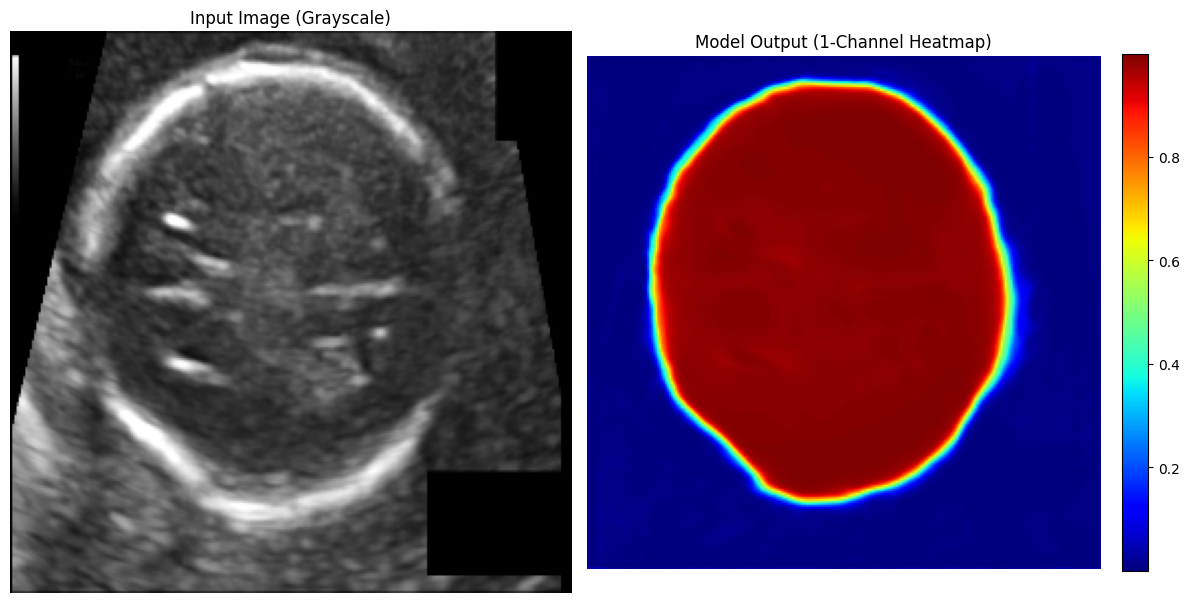

In [8]:
# 1. Path and Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Load the Model State
# Assuming 'model' and 'optimizer' are already defined in your script
checkpoint = torch.load(model_save_path, map_location=device)

# Handle different checkpoint formats (check if it's a dict or just the state_dict)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

# 3. Perform Inference
# Ensure input is (Batch, Channel, H, W) -> e.g., (1, 1, H, W)
test_input_tensor = test_input_tensor.to(device)

with torch.no_grad():
    output_tensor = model(test_input_tensor)

    # If this is binary segmentation, apply sigmoid to get values between 0 and 1
    # output_tensor = torch.sigmoid(output_tensor)

# 4. Post-processing
# Move to CPU and remove dimensions to get a 2D (H, W) array
output_np = output_tensor.cpu().squeeze().numpy()
input_np = test_input_tensor.cpu().squeeze().numpy()

# 5. Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Display the Input
axes[0].imshow(input_np, cmap='gray')
axes[0].set_title('Input Image (Grayscale)')
axes[0].axis('off')

# Display 1-Channel Output using a Colormap
# 'viridis' or 'magma' are great for visibility; 'gray' is standard for masks
im = axes[1].imshow(output_np, cmap='jet')
axes[1].set_title('Model Output (1-Channel Heatmap)')
axes[1].axis('off')

# Add a colorbar to show intensity values
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
# --- 4. Post-processing (Updated for Overlay) ---
# Assuming binary segmentation: threshold the output to get a 0/1 mask
threshold = 0.5
# If your model doesn't have a final sigmoid, use: torch.sigmoid(output_tensor)
mask_np = (output_tensor.cpu().squeeze() > threshold).numpy().astype(np.uint8)
input_np = test_input_tensor.cpu().squeeze().numpy()

# --- 5. Visualization (Overlay) ---
plt.figure(figsize=(8, 8))
plt.imshow(input_np, cmap='gray') # Base image
plt.imshow(mask_np, cmap='jet', alpha=0.3) # Overlay mask with 30% opacity
plt.title('Mask Overlaid on Input')
plt.axis('off')
plt.show()

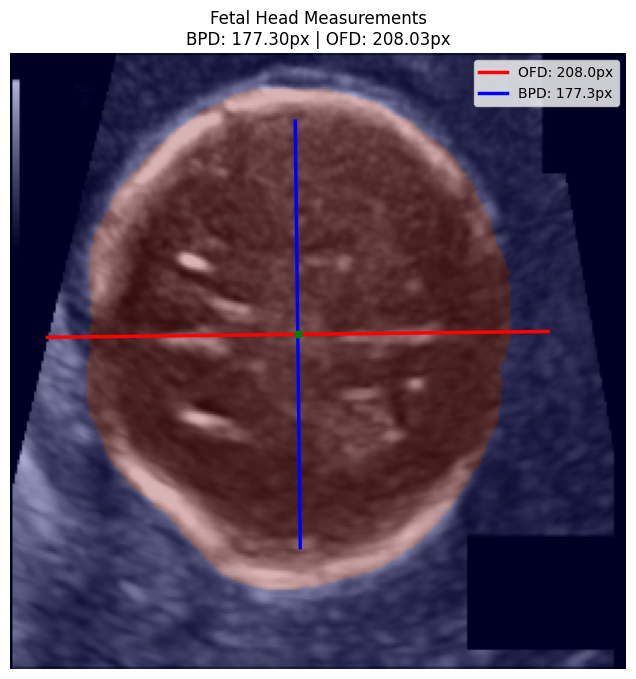

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math
from skimage.measure import label, regionprops

# 1. Process the mask
label_img = label(mask_np)
props = regionprops(label_img)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(input_np, cmap='gray')
ax.imshow(mask_np, cmap='jet', alpha=0.3) # Overlay mask

if len(props) > 0:
    # Get the largest object
    obj = max(props, key=lambda x: x.area)
    y0, x0 = obj.centroid
    orientation = obj.orientation
    major_axis = obj.major_axis_length
    minor_axis = obj.minor_axis_length

    # --- Calculate OFD Line (Major Axis) ---
    x1 = x0 + math.cos(orientation) * 0.5 * major_axis
    y1 = y0 - math.sin(orientation) * 0.5 * major_axis
    x2 = x0 - math.cos(orientation) * 0.5 * major_axis
    y2 = y0 + math.sin(orientation) * 0.5 * major_axis

    # --- Calculate BPD Line (Minor Axis) ---
    x3 = x0 + math.sin(orientation) * 0.5 * minor_axis
    y3 = y0 + math.cos(orientation) * 0.5 * minor_axis
    x4 = x0 - math.sin(orientation) * 0.5 * minor_axis
    y4 = y0 - math.cos(orientation) * 0.5 * minor_axis

    # 2. Draw the lines
    ax.plot((x1, x2), (y1, y2), '-r', linewidth=2.5, label=f'OFD: {major_axis:.1f}px')
    ax.plot((x3, x4), (y3, y4), '-b', linewidth=2.5, label=f'BPD: {minor_axis:.1f}px')

    # Plot the centroid
    ax.plot(x0, y0, '.g', markersize=10)

    ax.legend(loc='upper right')
    ax.set_title(f"Fetal Head Measurements\nBPD: {minor_axis:.2f}px | OFD: {major_axis:.2f}px")
else:
    ax.set_title("No Head Detected")

ax.axis('off')
plt.show()